In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
start = '1989-01-01'
end = '2023-12-31'

stock = 'MSFT'
data = yf.download(stock,start,end)

/var/folders/_k/41pjm0pd4051klhdyyg2vvzw0000gn/T/ipykernel_62826/3583337468.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace=True)

In [4]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT
0,1989-01-03,0.227480,0.228011,0.223768,0.226950,51825600
1,1989-01-04,0.230131,0.232782,0.226950,0.226950,53899200
2,1989-01-05,0.226420,0.232252,0.225890,0.232252,47246400
3,1989-01-06,0.224829,0.228011,0.224829,0.226950,59054400
4,1989-01-09,0.222708,0.225890,0.221117,0.224829,46008000
...,...,...,...,...,...,...
8812,2023-12-22,369.077087,369.668279,367.234564,368.190315,17107500
8813,2023-12-26,369.155914,371.402418,368.012952,369.490916,12673100
8814,2023-12-27,368.574615,369.550062,367.333116,368.200193,14905400


In [5]:
mva_days=data.Close.rolling(200).mean()
win_size=2
arr1=np.array(mva_days)
arr2=np.array(data.Close)

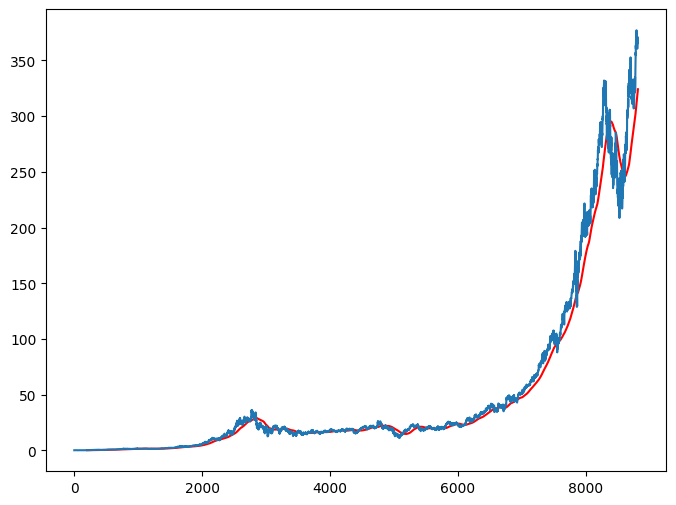

In [6]:
plt.figure(figsize=(8,6))
plt.plot(mva_days,'r')
plt.plot(data.Close)
plt.show()

In [7]:
'''# Checks if there is a local top detected at curr index
def rw_top(data: np.array, curr_index: int, order: int) -> bool:
    if curr_index < order * 2 + 1:
        return False

    top = True
    k = curr_index - order
    v = data[k]
    for i in range(1, order + 1):
        if data[k + i] > v or data[k - i] > v:
            top = False
            break
    
    return top

# Checks if there is a local top detected at curr index
def rw_bottom(data: np.array, curr_index: int, order: int) -> bool:
    if curr_index < order * 2 + 1:
        return False

    bottom = True
    k = curr_index - order
    v = data[k]
    for i in range(1, order + 1):
        if data[k + i] < v or data[k - i] < v:
            bottom = False
            break
    
    return bottom

def rw_extremes(data: np.array, order:int):
    # Rolling window local tops and bottoms
    tops = []
    bottoms = []
    for i in range(len(data)):
        if rw_top(data, i, order):
            # top[0] = confirmation index
            # top[1] = index of top
            # top[2] = price of top
            top = [i, i - order, data[i - order]]
            tops.append(top)
        
        if rw_bottom(data, i, order):
            # bottom[0] = confirmation index
            # bottom[1] = index of bottom
            # bottom[2] = price of bottom
            bottom = [i, i - order, data[i - order]]
            bottoms.append(bottom)
    
    return tops, bottoms


tops, bottoms=rw_extremes(arr2,1)

arr_tops=[]
arr_bottoms=[]
for i in range(len(tops)):
    arr_tops.append(tops[i][0])

for i in range(len(bottoms)):
    arr_bottoms.append(bottoms[i][0])
    
print(len(arr_tops),len(arr_bottoms))

print(arr_tops)
print(arr_bottoms)

ex=np.concatenate((arr_tops,arr_bottoms))

days_between = []
for i in range(len(tops)):

    days_between.append(abs(arr_bottoms[i]-arr_tops[i]))

        
print(days_between)
print(len(days_between))'''

'# Checks if there is a local top detected at curr index\ndef rw_top(data: np.array, curr_index: int, order: int) -> bool:\n    if curr_index < order * 2 + 1:\n        return False\n\n    top = True\n    k = curr_index - order\n    v = data[k]\n    for i in range(1, order + 1):\n        if data[k + i] > v or data[k - i] > v:\n            top = False\n            break\n    \n    return top\n\n# Checks if there is a local top detected at curr index\ndef rw_bottom(data: np.array, curr_index: int, order: int) -> bool:\n    if curr_index < order * 2 + 1:\n        return False\n\n    bottom = True\n    k = curr_index - order\n    v = data[k]\n    for i in range(1, order + 1):\n        if data[k + i] < v or data[k - i] < v:\n            bottom = False\n            break\n    \n    return bottom\n\ndef rw_extremes(data: np.array, order:int):\n    # Rolling window local tops and bottoms\n    tops = []\n    bottoms = []\n    for i in range(len(data)):\n        if rw_top(data, i, order):\n      

In [8]:
def directional_change(close: np.array, high: np.array, low: np.array, sigma: float):
    
    up_zig = True # Last extreme is a bottom. Next is a top. 
    tmp_max = high[0]
    tmp_min = low[0]
    tmp_max_i = 0
    tmp_min_i = 0

    tops = []
    bottoms = []

    for i in range(len(close)):
        if up_zig: # Last extreme is a bottom
            if high[i] > tmp_max:
                # New high, update 
                tmp_max = high[i]
                tmp_max_i = i
            elif close[i] < tmp_max - tmp_max * sigma: 
                # Price retraced by sigma %. Top confirmed, record it
                # top[0] = confirmation index
                # top[1] = index of top
                # top[2] = price of top
                top = [i, tmp_max_i, tmp_max]
                tops.append(top)

                # Setup for next bottom
                up_zig = False
                tmp_min = low[i]
                tmp_min_i = i
        else: # Last extreme is a top
            if low[i] < tmp_min:
                # New low, update 
                tmp_min = low[i]
                tmp_min_i = i
            elif close[i] > tmp_min + tmp_min * sigma: 
                # Price retraced by sigma %. Bottom confirmed, record it
                # bottom[0] = confirmation index
                # bottom[1] = index of bottom
                # bottom[2] = price of bottom
                bottom = [i, tmp_min_i, tmp_min]
                bottoms.append(bottom)

                # Setup for next top
                up_zig = True
                tmp_max = high[i]
                tmp_max_i = i

    return tops, bottoms

tops1, bottoms1 = directional_change(
    arr1, 
    data["High"].to_numpy(), 
    data["Low"].to_numpy(), 
    0.01
)


arr_tops1=[]
arr_bottoms1=[]
for i in range(len(tops1)):
    arr_tops1.append(tops1[i][0])

for i in range(len(bottoms1)):
    arr_bottoms1.append(bottoms1[i][0])
    

print(len(arr_tops1),len(arr_bottoms1))

extremes=np.concatenate((arr_tops1,arr_bottoms1))

print(arr_tops1)
print(arr_bottoms1)

days_between1 = []
if tops1[0][0]>bottoms1[0][0]:
    days_between1.append(bottoms1[0][0])
    for i in range(len(tops1)):
        days_between1.append(abs(arr_bottoms1[i]-arr_tops1[i]))
        days_between1.append(abs(arr_bottoms1[i]-arr_tops1[i-1]))

else:
    days_between1.append(bottoms1[0][0])
    for i in range(len(bottoms1)):
        days_between1.append(abs(arr_tops1[i]-arr_bottoms1[i]))
        days_between1.append(abs(arr_tops1[i]-arr_bottoms1[i-1]))

days_between1.pop(2)        
print(days_between1)
print(len(days_between1))
print(np.mean(days_between1))
print(np.std(days_between1))

count=0
day=np.array(days_between1)
for i in range(len(day)):
    if day[i]<1:
        count+=1
print(count)


197 196
[199, 280, 361, 420, 427, 434, 443, 458, 478, 520, 637, 673, 759, 869, 873, 879, 930, 936, 949, 954, 1045, 1051, 1075, 1093, 1109, 1195, 1206, 1209, 1238, 1246, 1271, 1306, 1318, 1365, 1452, 1529, 1577, 1653, 1723, 1744, 1756, 1763, 1771, 1783, 1792, 1830, 1901, 1953, 2039, 2139, 2258, 2276, 2290, 2325, 2413, 2472, 2498, 2548, 2655, 2708, 2739, 2744, 2756, 2784, 2823, 2825, 2828, 2838, 2927, 3011, 3072, 3108, 3197, 3236, 3245, 3273, 3316, 3327, 3355, 3467, 3493, 3536, 3547, 3587, 3592, 3596, 3598, 3605, 3609, 3648, 3654, 3668, 3691, 3767, 3774, 3821, 3862, 3897, 4004, 4132, 4171, 4224, 4252, 4342, 4449, 4513, 4594, 4619, 4681, 4684, 4686, 4691, 4722, 4751, 4869, 4935, 4989, 5058, 5135, 5147, 5249, 5372, 5384, 5507, 5528, 5613, 5626, 5632, 5673, 5716, 5720, 5728, 5734, 5744, 5782, 5809, 5897, 5927, 5938, 5952, 6033, 6112, 6131, 6252, 6308, 6350, 6437, 6528, 6631, 6686, 6732, 6748, 6801, 6843, 6899, 6905, 6925, 6941, 6991, 7078, 7173, 7255, 7343, 7426, 7499, 7529, 7534, 7565, 757

In [9]:
data_train = pd.DataFrame(days_between1[0: int(len(days_between1)*0.80)])
data_test = pd.DataFrame(days_between1[int(len(days_between1)*0.80): len(days_between1)])

In [10]:
data_train.shape[0]

313

In [11]:
data_test.shape[0]


79

In [12]:
from sklearn.preprocessing import MinMaxScaler as mms
scaler = mms(feature_range=(0,1))


In [13]:
data_train_scale=scaler.fit_transform(data_train)


In [14]:
x=[]
y=[]

for i in range (win_size,data_train_scale.shape[0]):
    x.append(data_train_scale[i-win_size:i])
    y.append(data_train_scale[i,0])
    

In [15]:
x, y = np.array(x), np.array(y)
x.shape[0]

311

In [16]:
import tensorflow.keras as keras
from keras.layers import Dense, Dropout,LSTM
from keras.models import Sequential

/Users/arpan25/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [17]:
model = Sequential()
model.add(LSTM(units = 50, return_sequences =True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, return_sequences =True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, return_sequences =True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, return_sequences =False))
model.add(Dropout(0.5))

model.add(Dense(units=1))

2025-12-22 11:02:12.870289: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-22 11:02:12.870324: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-22 11:02:12.870330: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-22 11:02:12.870361: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-22 11:02:12.870370: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/arpan25/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequenti

In [18]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')

In [19]:
hist = model.fit(x,y, epochs = 200, batch_size = 128 , verbose = 1)

Epoch 1/200


2025-12-22 11:02:13.750403: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 392ms/step - loss: 0.0141
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0139
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0105
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0106
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0112
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0112
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0106
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0103
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0103
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0114
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0113
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0115
Epoch 13/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0102
Epoch 14/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0108
Epoch 15/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0114
Epoch 16/200
3/3 ━━━━━━━━━━━━━

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 2, 60)          │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 60)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 2, 80)          │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [21]:
pst_days=data_train.tail(win_size)

In [22]:
data_test=pd.concat([pst_days,data_test],ignore_index=True)

In [23]:
data_test_scale =  scaler.fit_transform(data_test)

In [24]:
x=[]
y=[]

for i in range (win_size,data_test_scale.shape[0]):
    x.append(data_test_scale[i-win_size:i])
    y.append(data_test_scale[i,0])

x, y = np.array(x), np.array(y)

In [25]:
y_predict = model.predict(x)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step


In [26]:
scale=1/scaler.scale_
scale

array([102.])

In [27]:
y_predict=y_predict*scale

In [28]:
y=y*scale

In [29]:
print(data_test)
print('**')
for i in range (len(y_predict)):
    predict=np.ceil(y_predict).flatten()
print(y_predict)

     0
0    1
1    2
2    8
3   49
4   14
..  ..
76   6
77  82
78   4
79  85
80   1

[81 rows x 1 columns]
**
[[ 3.01751916]
 [ 4.16224194]
 [ 9.2670081 ]
 [17.67003527]
 [12.02146585]
 [20.67265847]
 [ 8.10261606]
 [21.07941601]
 [ 7.68144058]
 [20.38683477]
 [ 7.85128082]
 [20.67265847]
 [ 7.71623151]
 [20.44548842]
 [ 7.72600003]
 [19.72368979]
 [ 5.13916419]
 [14.19585434]
 [ 3.8278652 ]
 [ 4.7756681 ]
 [ 4.65525066]
 [12.34091927]
 [ 3.10938512]
 [ 4.8260458 ]
 [ 7.71693295]
 [ 6.10738644]
 [ 4.85544102]
 [ 3.56594373]
 [ 3.88699991]
 [ 8.82728353]
 [ 6.68199845]
 [17.35635146]
 [ 8.14370249]
 [20.50439742]
 [ 7.42573558]
 [19.93693739]
 [ 7.06472455]
 [18.30475625]
 [ 3.01751916]
 [ 3.56594373]
 [ 3.01751916]
 [ 3.65433953]
 [ 5.0004135 ]
 [11.47565478]
 [ 8.05671072]
 [19.57399151]
 [ 8.58728461]
 [21.26174542]
 [ 6.78125216]
 [17.61391684]
 [ 7.87206343]
 [20.00528964]
 [ 8.35800111]
 [21.47159448]
 [ 7.4533069 ]
 [15.43781465]
 [ 3.96817723]
 [ 9.24363631]
 [ 3.91302623]
 [ 5.

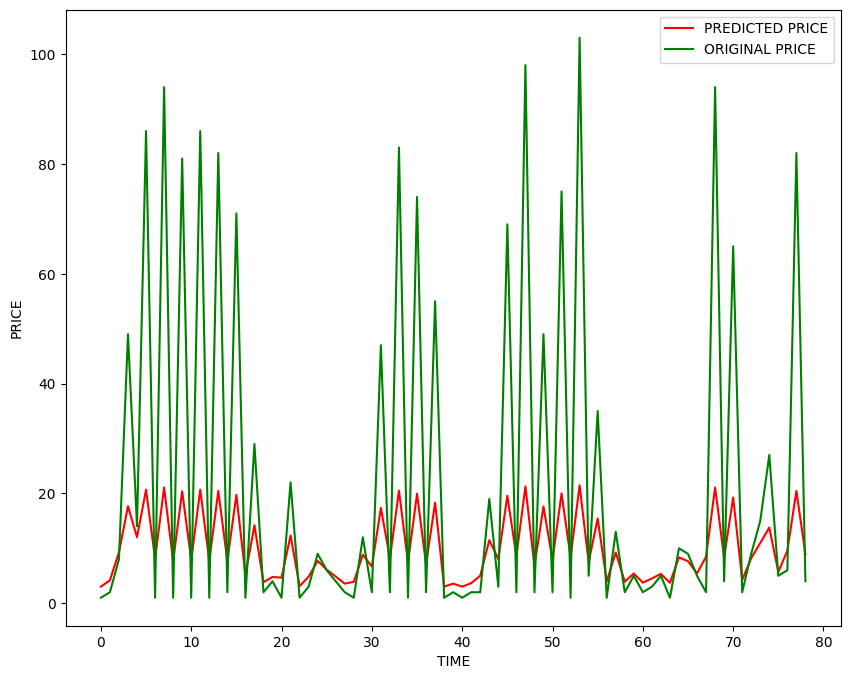

0.07962274724590446
31.08542741331305


79

In [30]:
data_days_array=np.array(data_test)
data_days=data_days_array[0:len(y_predict)]


plt.figure(figsize=(10,8))
plt.plot(y_predict,'r',label='PREDICTED PRICE')
plt.plot(data_days,'g',label='ORIGINAL PRICE')
plt.xlabel('TIME')
plt.ylabel('PRICE')
plt.legend()
plt.show()


from sklearn.metrics import r2_score as r2s
from sklearn.metrics import mean_squared_error as mse
r2 = r2s(y, predict)
mean_error = mse(y, predict)

print(r2)
print(np.sqrt(mean_error))
len(y_predict)

In [31]:
model.save('Stock days 2025.keras')